#### Exploratory Data Analysis (EDA)

This notebook explores patterns, distributions and relationships using the enriched datasets
from the feature engineering notebook.

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

BLUE   = "#1f77b4"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
RED    = "#d62728"
PURPLE = "#9467bd"
TEAL   = "#17becf"

In [2]:
# Load featured datasets 
sales     = pd.read_csv('sales_featured.csv',     parse_dates=['date'])
customers = pd.read_csv('customers_featured.csv', parse_dates=['first_purchase_date','last_purchase_date'])
products  = pd.read_csv('products_featured.csv')
expenses  = pd.read_csv('expenses_featured.csv',  parse_dates=['date'])
inventory = pd.read_csv('inventory_featured.csv', parse_dates=['date'])

# Restore period columns for grouping
sales['month']     = sales['date'].dt.to_period('M')
expenses['month']  = expenses['date'].dt.to_period('M')
inventory['month'] = inventory['date'].dt.to_period('M')


In [4]:
print(f"  sales cols     : {list(sales.columns)}")
print(f"  customer cols  : {list(customers.columns)}")
print(f"  inventory cols : {list(inventory.columns)}")
print(f"  expenses cols  : {list(expenses.columns)}")
print(f"  products cols  : {list(products.columns)}")

  sales cols     : ['sale_id', 'date', 'store_channel', 'payment_method', 'product_id', 'product_name', 'category', 'sub_category', 'quantity_sold', 'unit_price', 'discount_pct', 'discount_amount', 'total_sale', 'cost_total', 'gross_profit', 'customer_id', 'is_promotion', 'is_returned', 'net_profit', 'year', 'quarter', 'month_num', 'month_name', 'day_of_week', 'is_weekend', 'days_since_start', 'profit_margin_pct', 'revenue_per_unit', 'break_even_sale', 'profitability', 'season', 'catalogue_margin_pct', 'is_winter', 'is_summer', 'cost_price', 'margin_erosion', 'month']
  customer cols  : ['customer_id', 'name', 'email', 'age', 'gender', 'city', 'state', 'segment', 'total_items_purchased', 'total_spent', 'num_orders', 'last_purchase_date', 'favourite_category', 'first_purchase_date', 'avg_order_value', 'age_group', 'derived_segment', 'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment']
  inventory cols : ['date', 'product_id', 'product_name', 'categ

### Sales_ EDA

##### Data Overview

In [5]:
print(f"Transactions  : {len(sales):,}")
print(f"Date range    : {sales['date'].min().date()} to {sales['date'].max().date()}")
print(f"Total revenue : ${sales['total_sale'].sum():,.2f}")
print(f"Total net profit: ${sales['net_profit'].sum():,.2f}")
print(f"Avg order value : ${sales['total_sale'].mean():.2f}")
print(f"Avg profit margin: {sales[sales['net_profit']>0]['profit_margin_pct'].mean():.1f}%")
print(f"Return rate   : {sales['is_returned'].mean()*100:.1f}%")
print(f"Promotion rate: {sales['is_promotion'].mean()*100:.1f}%")

Transactions  : 9,989
Date range    : 2024-01-01 to 2025-06-30
Total revenue : $672,108.94
Total net profit: $402,839.75
Avg order value : $67.28
Avg profit margin: 64.5%
Return rate   : 4.8%
Promotion rate: 26.9%


##### 1. Monthly Revenue & Profit Trend

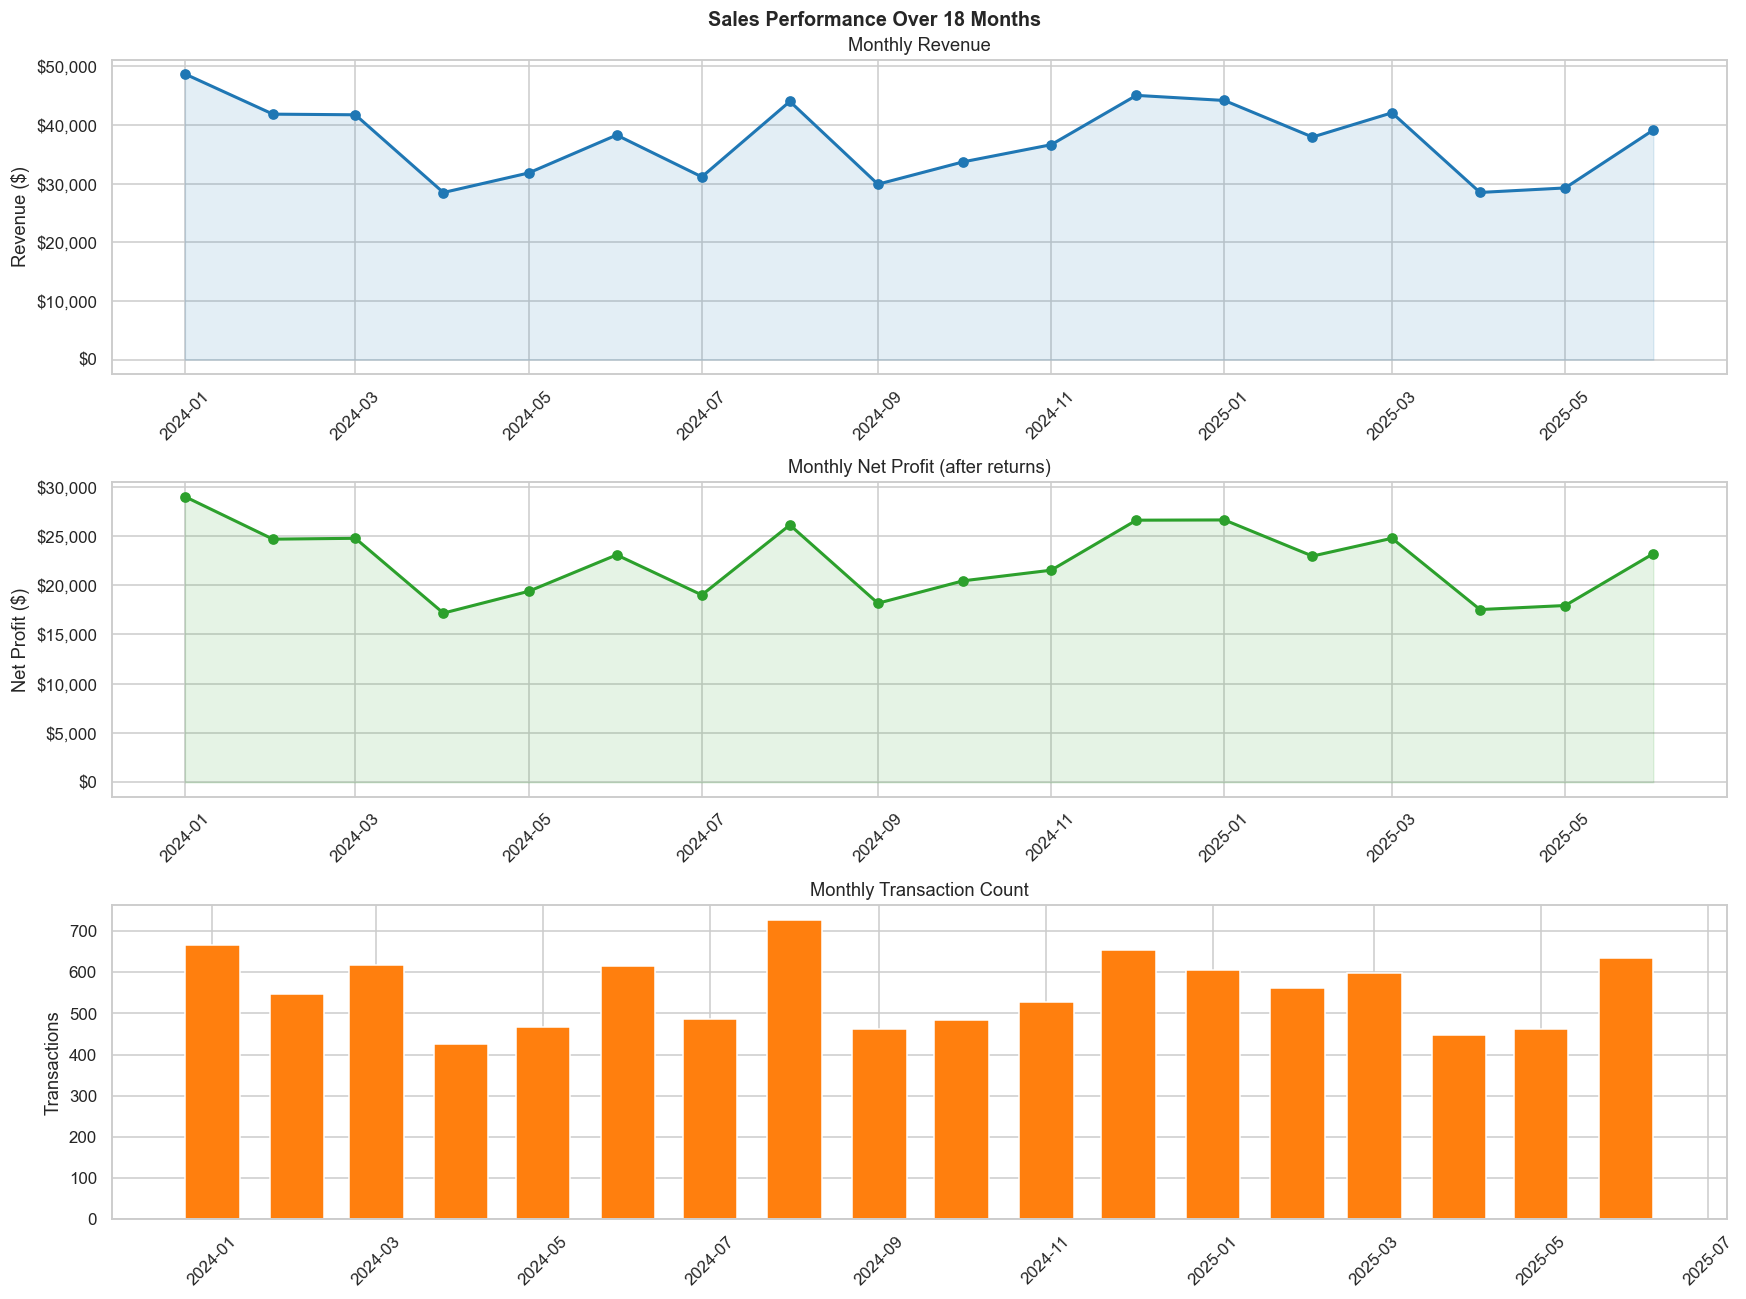

In [6]:
monthly = sales.groupby('month').agg(
    transactions  = ('sale_id', 'count'),
    revenue       = ('total_sale', 'sum'),
    net_profit    = ('net_profit', 'sum'),
    avg_margin    = ('profit_margin_pct', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(monthly['month_dt'], monthly['revenue'], color=BLUE, marker='o', linewidth=2)
axes[0].fill_between(monthly['month_dt'], monthly['revenue'], alpha=0.12, color=BLUE)
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['month_dt'], monthly['net_profit'], color=GREEN, marker='o', linewidth=2)
axes[1].fill_between(monthly['month_dt'], monthly['net_profit'], alpha=0.12, color=GREEN)
axes[1].set_title("Monthly Net Profit (after returns)")
axes[1].set_ylabel("Net Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(monthly['month_dt'], monthly['transactions'], color=ORANGE, width=20)
axes[2].set_title("Monthly Transaction Count")
axes[2].set_ylabel("Transactions")
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("Sales Performance Over 18 Months", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- For months where revenue peaks but net profit doesn't, it indicates either a high return month or a high-discount month where top-line revenue grows but margin is compressed. The transaction count chart separates volume from value changes.

##### 2. Quarterly Performance

Quarterly Performance Summary:
  label  transactions   revenue  net_profit  avg_margin  return_rate
2024 Q1          1831 132219.67    78410.21        61.0          4.6
2024 Q2          1506  98533.19    59612.77        61.7          4.8
2024 Q3          1676 105023.95    63279.49        61.3          5.2
2024 Q4          1666 115339.22    68553.67        61.6          4.4
2025 Q1          1764 124138.60    74329.02        61.0          4.9
2025 Q2          1546  96854.31    58654.59        61.7          5.1


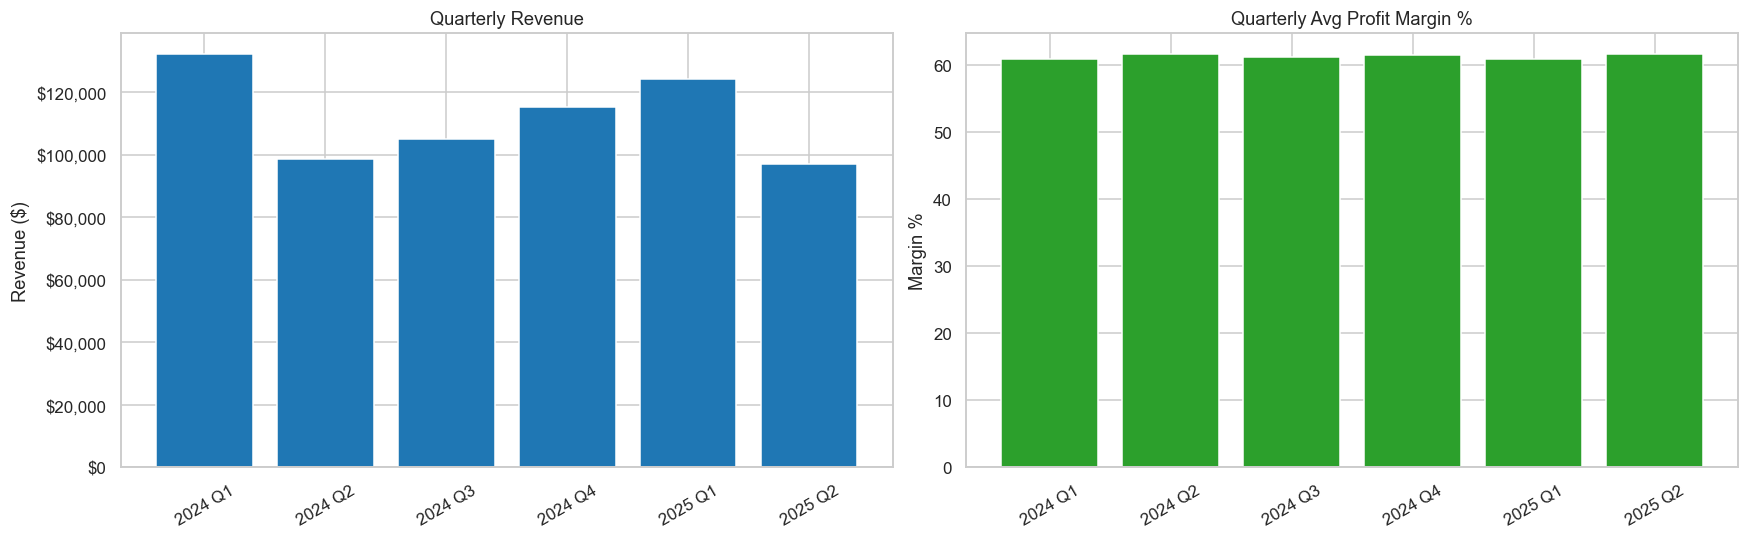

In [7]:
quarterly = sales.groupby(['year','quarter']).agg(
    transactions  = ('sale_id', 'count'),
    revenue       = ('total_sale', 'sum'),
    net_profit    = ('net_profit', 'sum'),
    avg_margin    = ('profit_margin_pct', 'mean'),
    return_rate   = ('is_returned', 'mean')
).reset_index()
quarterly['return_rate'] = (quarterly['return_rate'] * 100).round(1)
quarterly['avg_margin']  = quarterly['avg_margin'].round(1)
quarterly['label'] = quarterly['year'].astype(str) + ' Q' + quarterly['quarter'].astype(str)

print("Quarterly Performance Summary:")
print(quarterly[['label','transactions','revenue','net_profit','avg_margin','return_rate']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(quarterly['label'], quarterly['revenue'], color=BLUE)
axes[0].set_title("Quarterly Revenue")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(quarterly['label'], quarterly['avg_margin'], color=GREEN)
axes[1].set_title("Quarterly Avg Profit Margin %")
axes[1].set_ylabel("Margin %")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

##### 3. Day-of-Week & Weekend Patterns

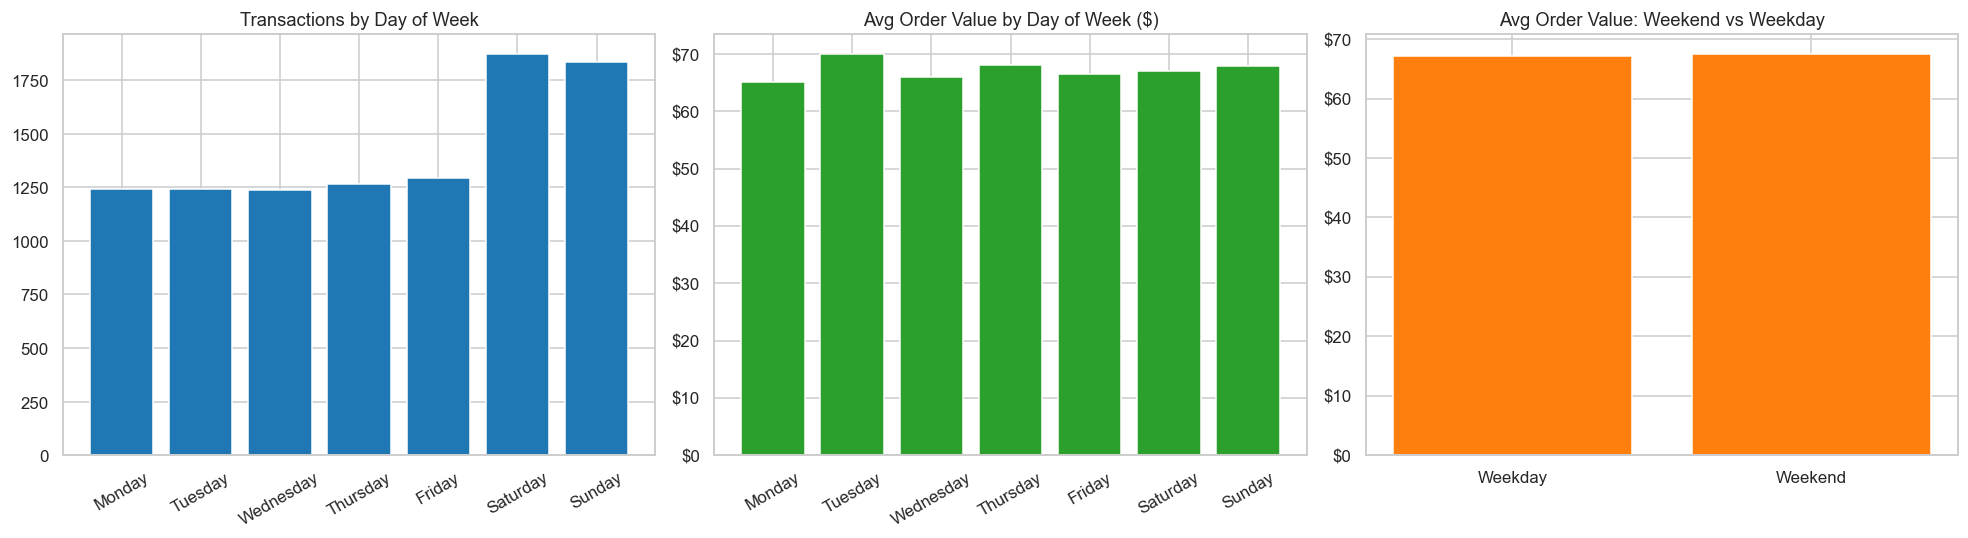

In [8]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = sales.groupby('day_of_week').agg(
    transactions    = ('sale_id', 'count'),
    avg_order_value = ('total_sale', 'mean'),
    avg_margin      = ('profit_margin_pct', 'mean')
).reindex(dow_order).reset_index()

weekend_vs_week = sales.groupby('is_weekend').agg(
    transactions    = ('sale_id', 'count'),
    avg_order_value = ('total_sale', 'mean'),
    total_revenue   = ('total_sale', 'sum')
).reset_index()
weekend_vs_week['label'] = weekend_vs_week['is_weekend'].map({True:'Weekend', False:'Weekday'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(dow['day_of_week'], dow['transactions'], color=BLUE)
axes[0].set_title("Transactions by Day of Week")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow['day_of_week'], dow['avg_order_value'], color=GREEN)
axes[1].set_title("Avg Order Value by Day of Week ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(weekend_vs_week['label'], weekend_vs_week['avg_order_value'], color=ORANGE)
axes[2].set_title("Avg Order Value: Weekend vs Weekday")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

plt.tight_layout()
plt.show()

In [9]:
print(dow[['day_of_week','transactions','avg_order_value','avg_margin']].to_string(index=False))

day_of_week  transactions  avg_order_value  avg_margin
     Monday          1244        65.191608   61.306929
    Tuesday          1244        69.978103   61.537484
  Wednesday          1236        66.005882   61.383706
   Thursday          1266        68.062536   60.971074
     Friday          1295        66.593730   60.693073
   Saturday          1871        67.012229   61.767424
     Sunday          1833        67.969787   61.511457


##### 4.  Channel Performance

Channel Summary:
store_channel  transactions  total_revenue  total_net_profit  avg_order_value  avg_margin  return_rate
       Online          4547      310378.98         185226.35        68.260167        61.1          5.2
     Physical          5442      361729.96         217613.40        66.470040        61.6          4.5


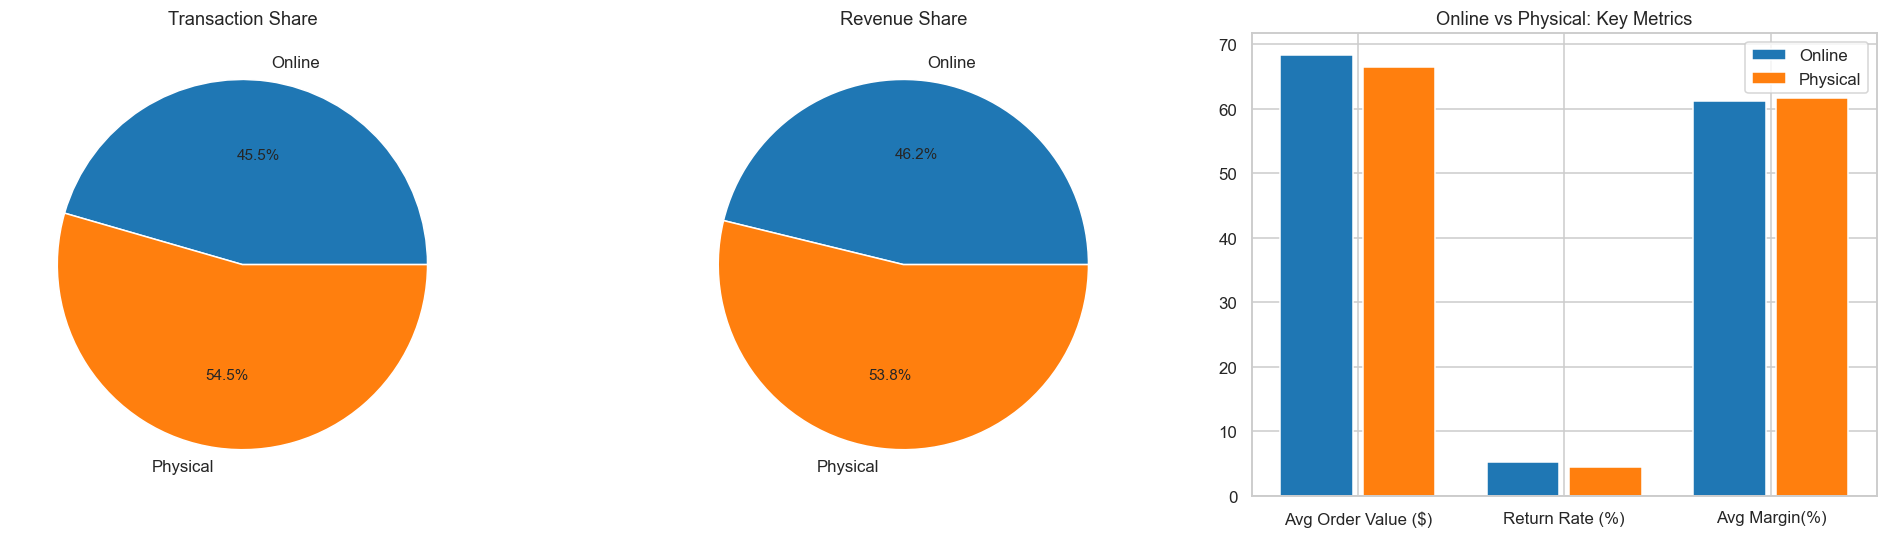

In [11]:
channel = sales.groupby('store_channel').agg(
    transactions     = ('sale_id', 'count'),
    total_revenue    = ('total_sale', 'sum'),
    total_net_profit = ('net_profit', 'sum'),
    avg_order_value  = ('total_sale', 'mean'),
    avg_margin       = ('profit_margin_pct', 'mean'),
    return_rate      = ('is_returned', 'mean')
).reset_index()
channel['return_rate'] = (channel['return_rate'] * 100).round(1)
channel['avg_margin']  = channel['avg_margin'].round(1)
print("Channel Summary:")
print(channel.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].pie(channel['transactions'], labels=channel['store_channel'],
            autopct='%1.1f%%', colors=[BLUE, ORANGE])
axes[0].set_title("Transaction Share")

axes[1].pie(channel['total_revenue'], labels=channel['store_channel'],
            autopct='%1.1f%%', colors=[BLUE, ORANGE])
axes[1].set_title("Revenue Share")

metrics = ['avg_order_value', 'return_rate', 'avg_margin']
labels  = ['Avg Order Value ($)', 'Return Rate (%)', 'Avg Margin(%)']
x = range(len(metrics))
online_vals   = [channel[channel['store_channel']=='Online'][m].values[0] for m in metrics]
physical_vals = [channel[channel['store_channel']=='Physical'][m].values[0] for m in metrics]
axes[2].bar([i-0.2 for i in x], online_vals,   0.35, label='Online',   color=BLUE)
axes[2].bar([i+0.2 for i in x], physical_vals, 0.35, label='Physical', color=ORANGE)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels)
axes[2].set_title("Online vs Physical: Key Metrics")
axes[2].legend()
plt.tight_layout()
plt.show()

##### 5. Discount Analysis: Volume, Margin, and Erosion

Discount Tier Analysis:
 discount_pct  transactions  avg_units_sold  avg_net_profit  avg_margin  avg_erosion  return_rate
            0          4489        1.811985       42.310033   63.104798     3.373927          5.1
            5          2189        1.870260       40.483207   61.860251     4.732668          4.6
           10          1829        1.926189       39.470148   59.843603     6.606862          4.6
           15          1127        1.924579       35.218234   57.581526     8.961863          5.1
           20           355        2.123944       34.958930   55.648197    10.869831          4.2


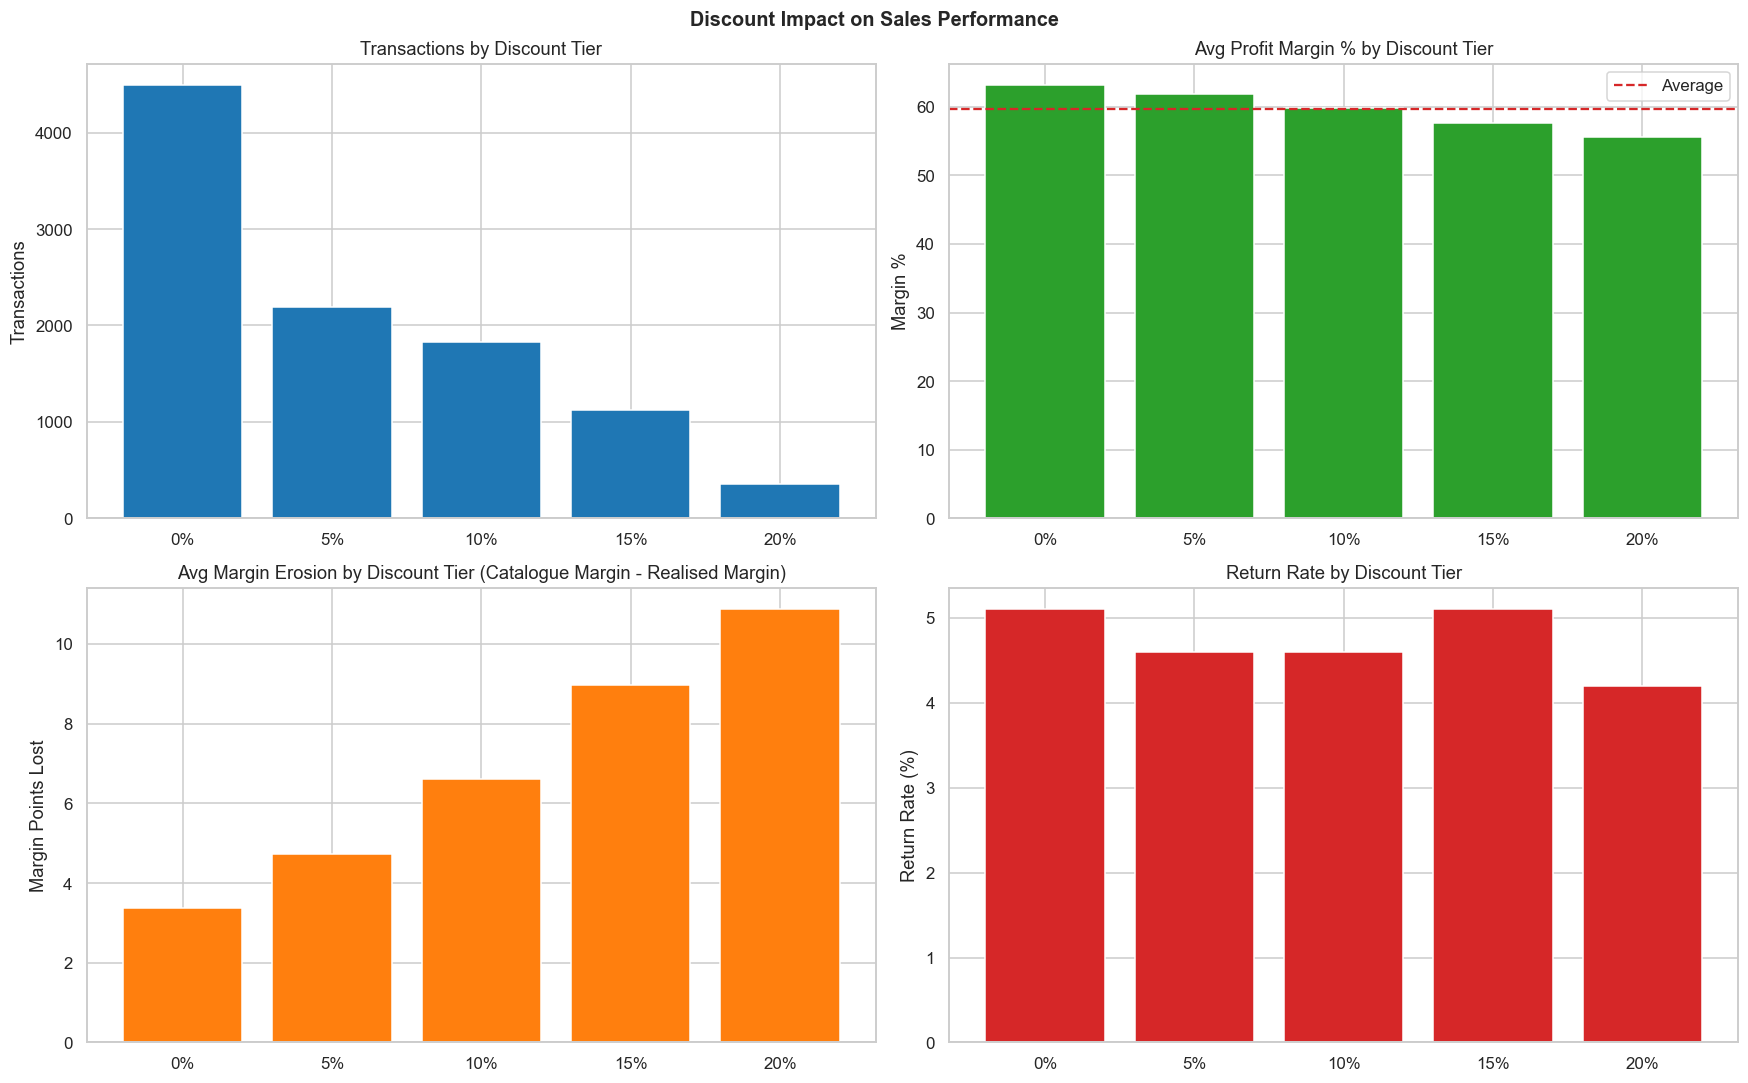

In [13]:
discount = sales.groupby('discount_pct').agg(
    transactions     = ('sale_id', 'count'),
    avg_units_sold   = ('quantity_sold', 'mean'),
    avg_net_profit   = ('net_profit', 'mean'),
    avg_margin       = ('profit_margin_pct', 'mean'),
    avg_erosion      = ('margin_erosion', 'mean'),
    return_rate      = ('is_returned', 'mean')
).reset_index()
discount['return_rate'] = (discount['return_rate'] * 100).round(1)

print("Discount Tier Analysis:")
print(discount.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = discount['discount_pct'].astype(str) + '%'

axes[0,0].bar(x, discount['transactions'], color=BLUE)
axes[0,0].set_title("Transactions by Discount Tier")
axes[0,0].set_ylabel("Transactions")

axes[0,1].bar(x, discount['avg_margin'], color=GREEN)
axes[0,1].set_title("Avg Profit Margin % by Discount Tier")
axes[0,1].set_ylabel("Margin %")
axes[0,1].axhline(discount['avg_margin'].mean(), color=RED, linestyle='--', label='Average')
axes[0,1].legend()

axes[1,0].bar(x, discount['avg_erosion'], color=ORANGE)
axes[1,0].set_title("Avg Margin Erosion by Discount Tier (Catalogue Margin - Realised Margin)")
axes[1,0].set_ylabel("Margin Points Lost")

axes[1,1].bar(x, discount['return_rate'], color=RED)
axes[1,1].set_title("Return Rate by Discount Tier")
axes[1,1].set_ylabel("Return Rate (%)")

plt.suptitle("Discount Impact on Sales Performance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

-  **Margin_erosion** shows exactly how many margin points are lost at each discount tier. If erosion is disproportionately high at 20% discounts without a matching jump in transaction volume, the 20% tier is destroying more value than it creates.

### Customer EDA

##### 1. Demographics

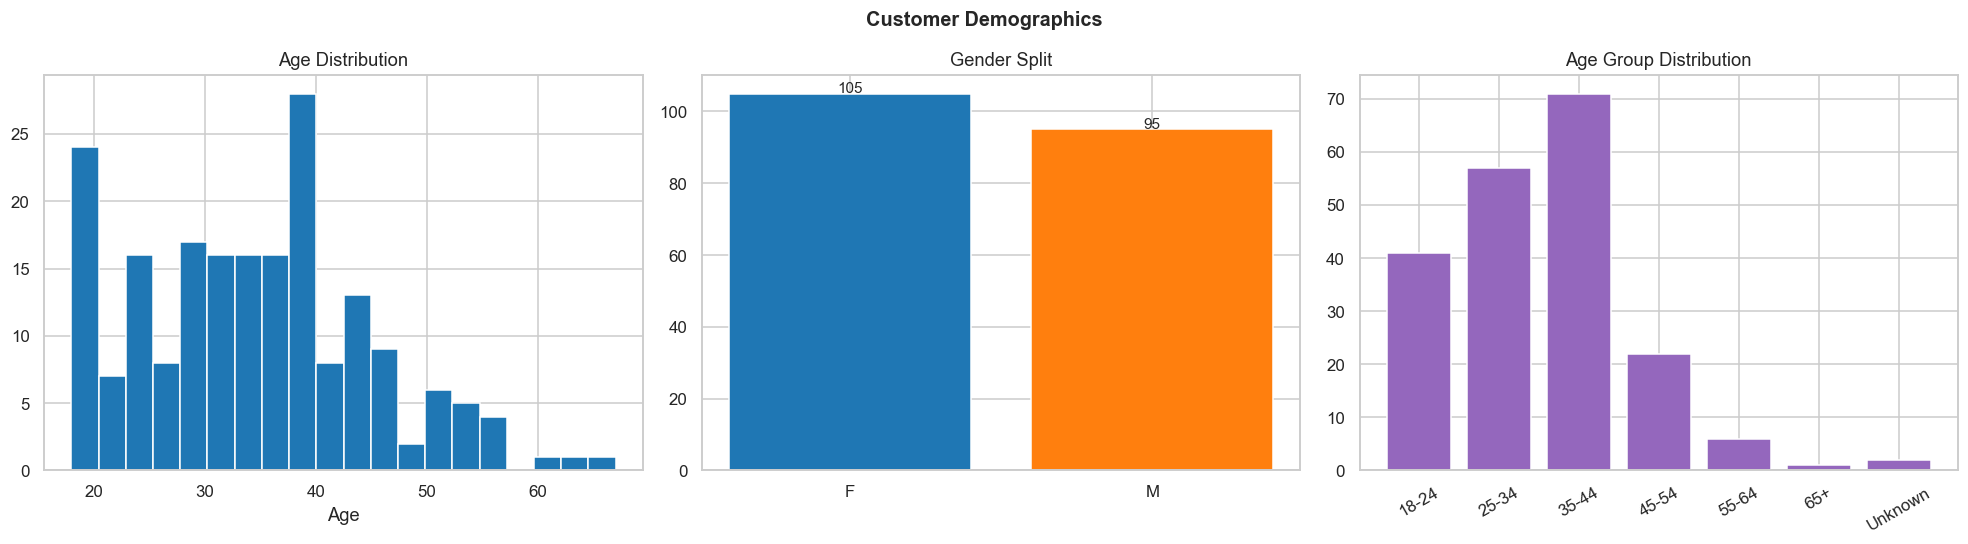

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(customers['age'].dropna(), bins=20, color=BLUE, edgecolor='white')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Gender
gender_counts = customers['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=[BLUE, ORANGE])
axes[1].set_title("Gender Split")
for bar, val in zip(axes[1].patches, gender_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center')

# Age group
age_order = ['18-24','25-34','35-44','45-54','55-64','65+','Unknown']
age_counts = customers['age_group'].value_counts().reindex(age_order).dropna()
axes[2].bar(age_counts.index, age_counts.values, color=PURPLE)
axes[2].set_title("Age Group Distribution")
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Customer Demographics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 2. RFM Segment Analysis

RFM Segment Profile:
RFM_segment  count  avg_recency  avg_orders  avg_spent  avg_tenure
   Champion     12          3.2        63.9     5026.6       535.5
      Loyal     66          6.2        53.6     3910.6       535.0
  Potential     54         13.3        49.9     3337.5       526.6
    At Risk     42         13.6        45.4     2693.3       526.9
       Lost     26         25.2        41.8     2320.9       518.1


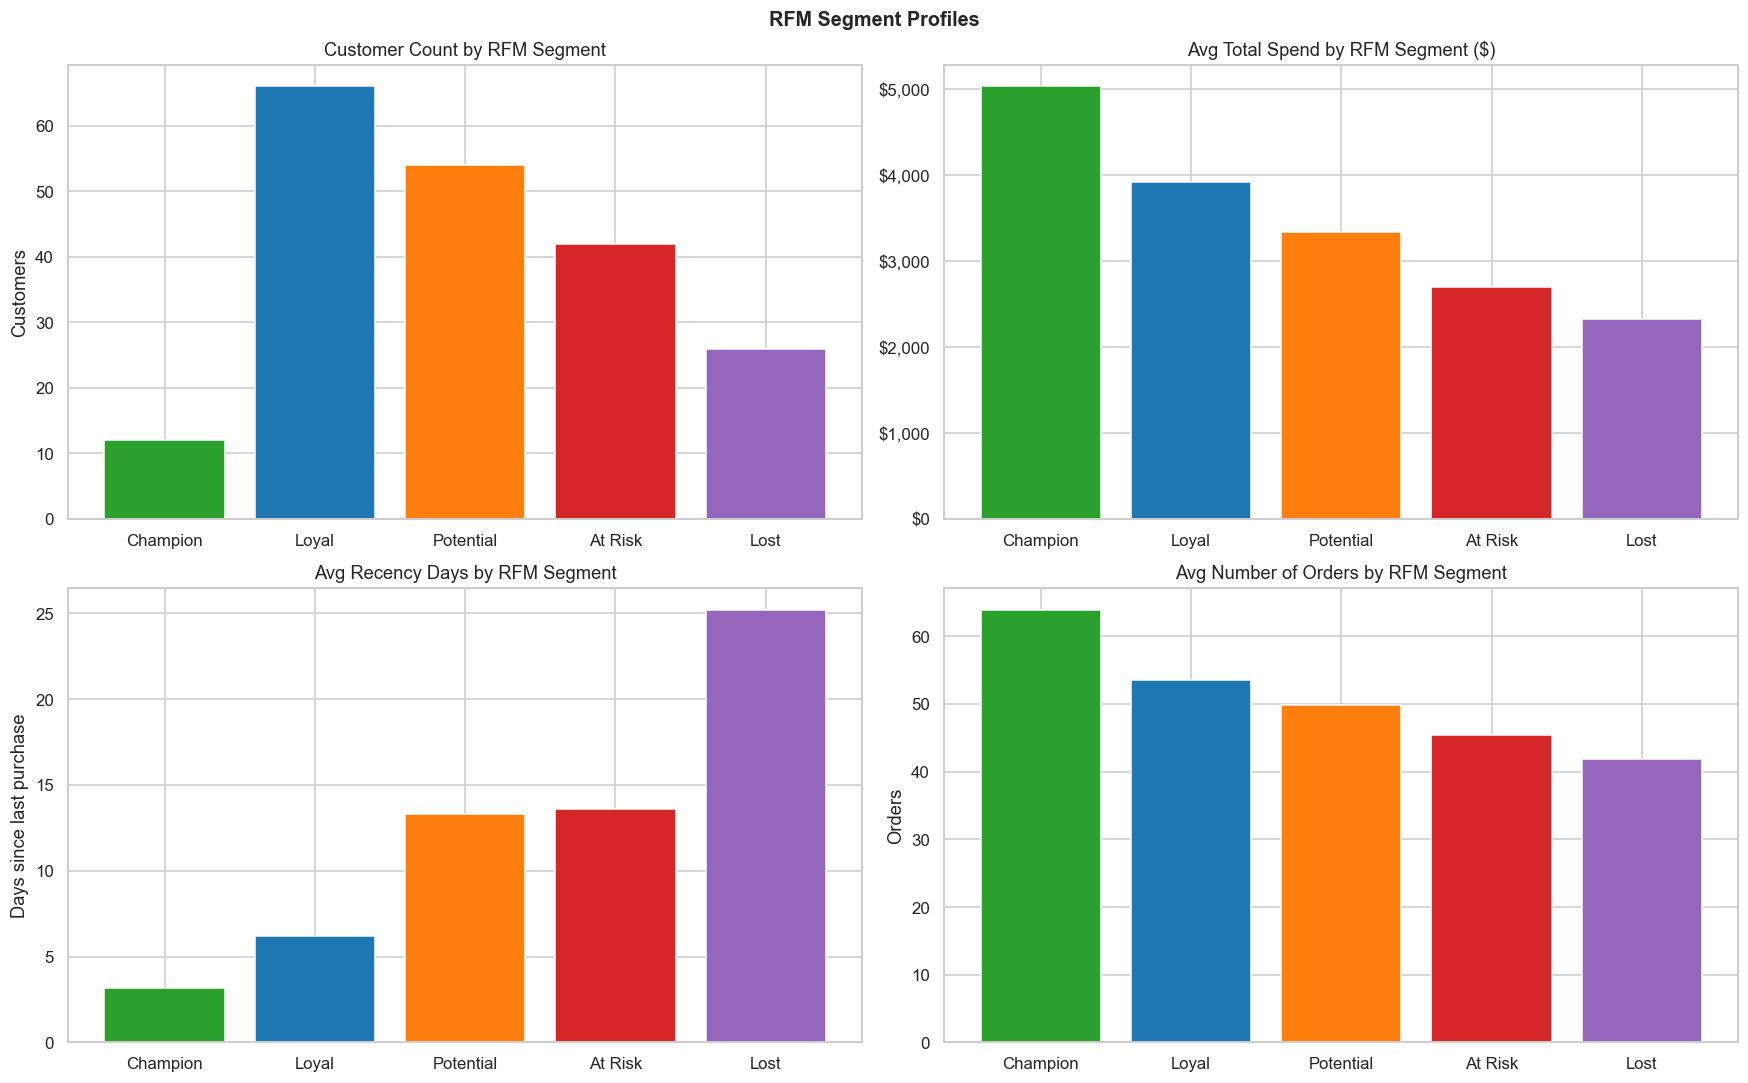

In [15]:
# RFM segment distribution and spending profile
rfm_profile = customers.groupby('RFM_segment').agg(
    count        = ('customer_id', 'count'),
    avg_recency  = ('recency_days', 'mean'),
    avg_orders   = ('num_orders', 'mean'),
    avg_spent    = ('total_spent', 'mean'),
    avg_tenure   = ('tenure_days', 'mean')
).round(1).reset_index()

seg_order = ['Champion','Loyal','Potential','At Risk','Lost']
rfm_profile['RFM_segment'] = pd.Categorical(rfm_profile['RFM_segment'], categories=seg_order, ordered=True)
rfm_profile = rfm_profile.sort_values('RFM_segment')

print("RFM Segment Profile:")
print(rfm_profile.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = [GREEN, BLUE, ORANGE, RED, PURPLE]

axes[0,0].bar(rfm_profile['RFM_segment'], rfm_profile['count'], color=colors)
axes[0,0].set_title("Customer Count by RFM Segment")
axes[0,0].set_ylabel("Customers")

axes[0,1].bar(rfm_profile['RFM_segment'], rfm_profile['avg_spent'], color=colors)
axes[0,1].set_title("Avg Total Spend by RFM Segment ($)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1,0].bar(rfm_profile['RFM_segment'], rfm_profile['avg_recency'], color=colors)
axes[1,0].set_title("Avg Recency Days by RFM Segment")
axes[1,0].set_ylabel("Days since last purchase")

axes[1,1].bar(rfm_profile['RFM_segment'], rfm_profile['avg_orders'], color=colors)
axes[1,1].set_title("Avg Number of Orders by RFM Segment")
axes[1,1].set_ylabel("Orders")

plt.suptitle("RFM Segment Profiles", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Champions should have low recency (bought recently), high orders, and high spend. At Risk customers will have high spend and orders historically but much higher recency days because they were once valuable but are drifting away. 

##### 3. Spending Distribution & Lifetime Value

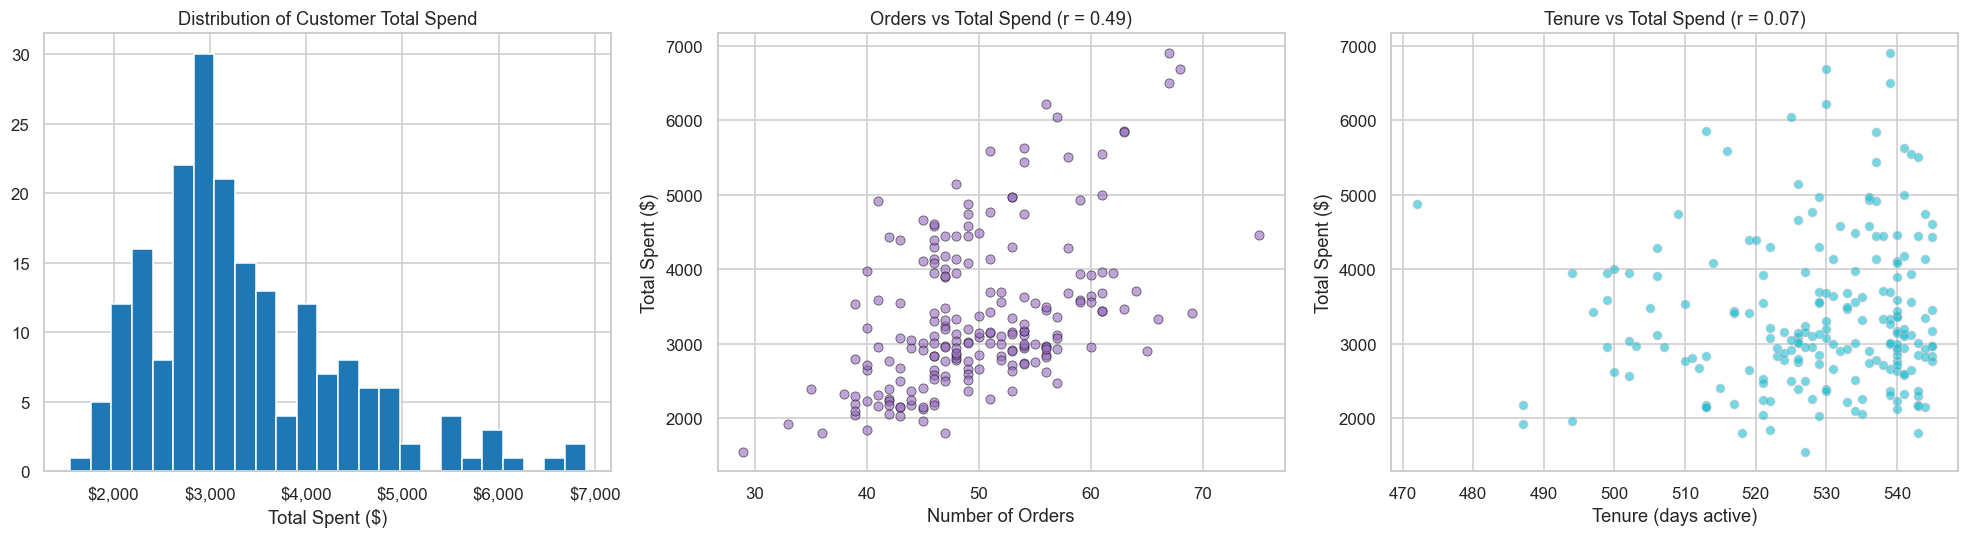

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total spend distribution
axes[0].hist(customers['total_spent'], bins=25, color=BLUE, edgecolor='white')
axes[0].set_title("Distribution of Customer Total Spend")
axes[0].set_xlabel("Total Spent ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Orders vs total spend scatter
axes[1].scatter(customers['num_orders'], customers['total_spent'], alpha=0.6,
                color=PURPLE, edgecolors='black', linewidths=0.5)
corr = customers['num_orders'].corr(customers['total_spent'])
axes[1].set_title(f"Orders vs Total Spend (r = {corr:.2f})")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Total Spent ($)")

# Tenure vs total spend
axes[2].scatter(customers['tenure_days'], customers['total_spent'], alpha=0.6,
                color=TEAL, edgecolors='pink', linewidths=0.5)
corr2 = customers['tenure_days'].corr(customers['total_spent'])
axes[2].set_title(f"Tenure vs Total Spend (r = {corr2:.2f})")
axes[2].set_xlabel("Tenure (days active)")
axes[2].set_ylabel("Total Spent ($)")

plt.tight_layout()
plt.show()

##### 4. Favourite Category & Geography

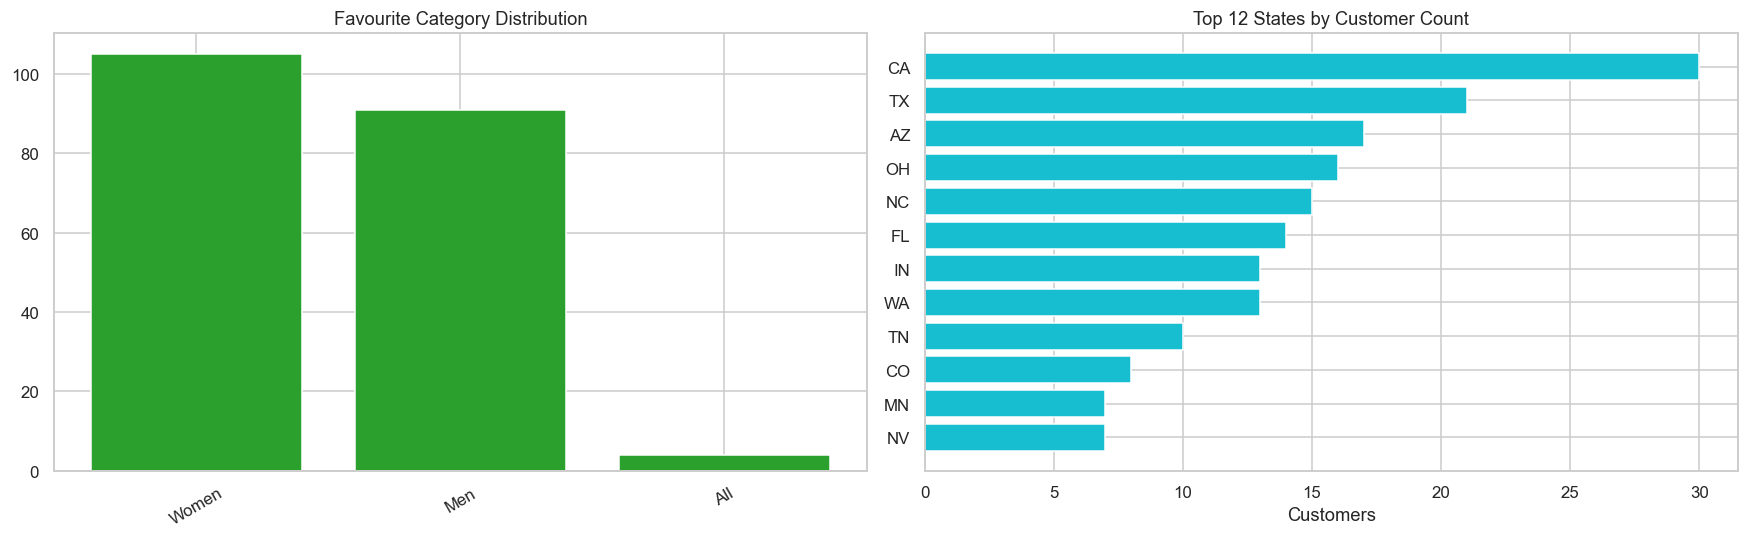

Favourite category by RFM segment:
RFM_segment favourite_category  count
    At Risk              Women     22
    At Risk                Men     19
   Champion              Women      8
   Champion                Men      4
       Lost              Women     13
       Lost                Men     12
      Loyal                Men     36
      Loyal              Women     28
  Potential              Women     34
  Potential                Men     20


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fav_cat = customers['favourite_category'].value_counts()
axes[0].bar(fav_cat.index, fav_cat.values, color=GREEN)
axes[0].set_title("Favourite Category Distribution")
axes[0].tick_params(axis='x', rotation=30)

top_states = customers['state'].value_counts().head(12)
axes[1].barh(top_states.index[::-1], top_states.values[::-1], color=TEAL)
axes[1].set_title("Top 12 States by Customer Count")
axes[1].set_xlabel("Customers")

plt.tight_layout()
plt.show()

print("Favourite category by RFM segment:")
print(customers.groupby(['RFM_segment','favourite_category']).size()
      .reset_index(name='count')
      .sort_values(['RFM_segment','count'], ascending=[True,False])
      .groupby('RFM_segment').head(2)
      .to_string(index=False))

### Product EDA

In [23]:
print("Products by category:")
print(products['category'].value_counts().to_string())
print()
print("Products by season:")
print(products['season'].value_counts().to_string())
print()
print("Price and margin summary:")
print(products[['base_price','cost_price','profit_per_unit','profit_margin_pct']].describe().round(2))

Products by category:
category
Women    9
Men      8
Kids     4
All      4

Products by season:
season
All       13
Winter     6
Summer     6

Price and margin summary:
       base_price  cost_price  profit_per_unit  profit_margin_pct
count       25.00       25.00            25.00               25.0
mean        40.59       14.42            26.17               65.6
std         20.22        8.02            12.23                3.2
min          9.99        2.50             7.49               61.1
25%         24.99        9.00            16.99               63.6
50%         39.99       14.00            25.99               64.4
75%         49.99       18.00            31.99               66.7
max         89.99       35.00            54.99               75.0


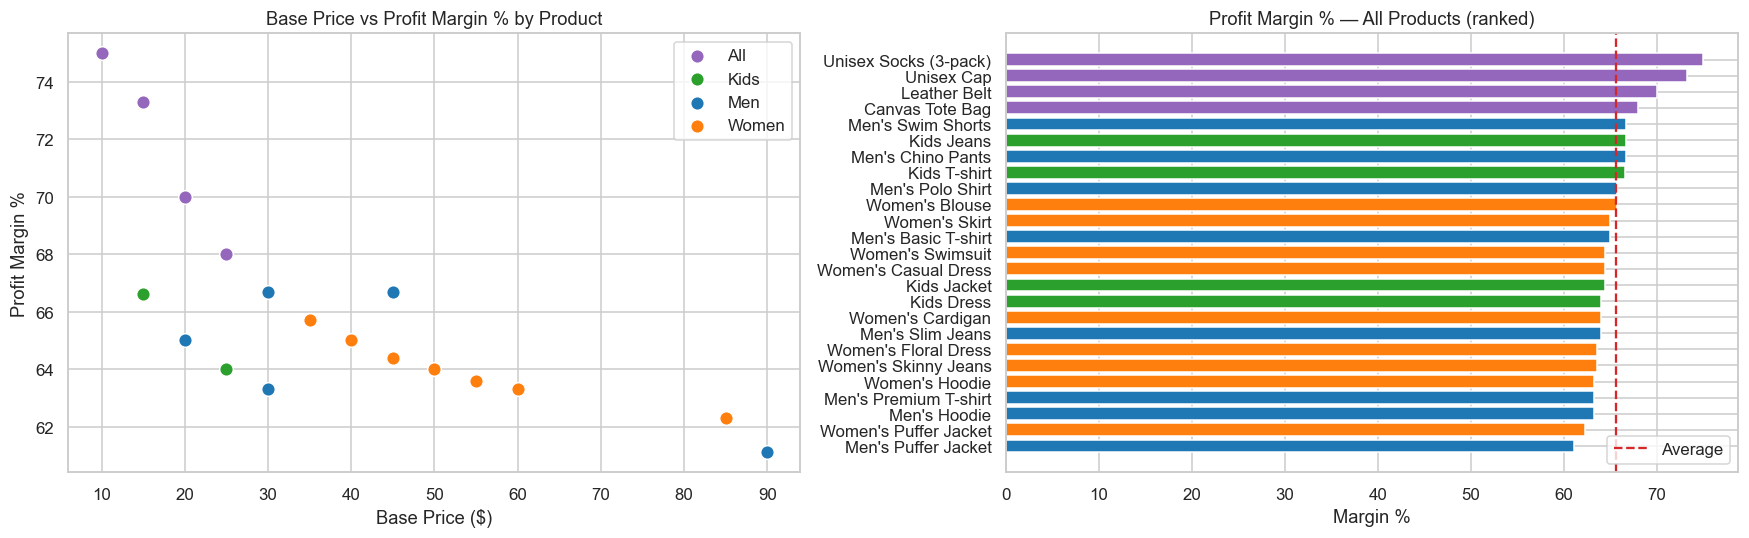

In [24]:
# Price vs margin scatter — are higher-priced products also higher-margin?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_colors = {'Men': BLUE, 'Women': ORANGE, 'Kids': GREEN, 'All': PURPLE}
for cat, grp in products.groupby('category'):
    axes[0].scatter(grp['base_price'], grp['profit_margin_pct'],
                    label=cat, color=cat_colors[cat], s=80, edgecolors='white')

axes[0].set_title("Base Price vs Profit Margin % by Product")
axes[0].set_xlabel("Base Price ($)")
axes[0].set_ylabel("Profit Margin %")
axes[0].legend()

# All products margin ranked
prod_sorted = products.sort_values('profit_margin_pct')
colors_bar = [cat_colors[c] for c in prod_sorted['category']]
axes[1].barh(prod_sorted['product_name'], prod_sorted['profit_margin_pct'], color=colors_bar)
axes[1].set_title("Profit Margin % — All Products (ranked)")
axes[1].set_xlabel("Margin %")
axes[1].axvline(products['profit_margin_pct'].mean(), color=RED, linestyle='--', label='Average')
axes[1].legend()

plt.tight_layout()
plt.show()

### Expenses EDA

Fixed vs Variable Cost Split:
                 sum     mean   pct
cost_type                          
Fixed       72900.00  1350.00  13.3
Variable   474579.42   374.27  86.7

By Category:
                category cost_type    amount
      Cost of Goods Sold  Variable 249989.00
                 Payroll  Variable 187300.32
                    Rent     Fixed  63000.00
    Shipping & Packaging  Variable  15870.57
               Marketing  Variable  15064.49
               Insurance     Fixed   7200.00
               Utilities  Variable   6355.04
Software & Subscriptions     Fixed   2700.00


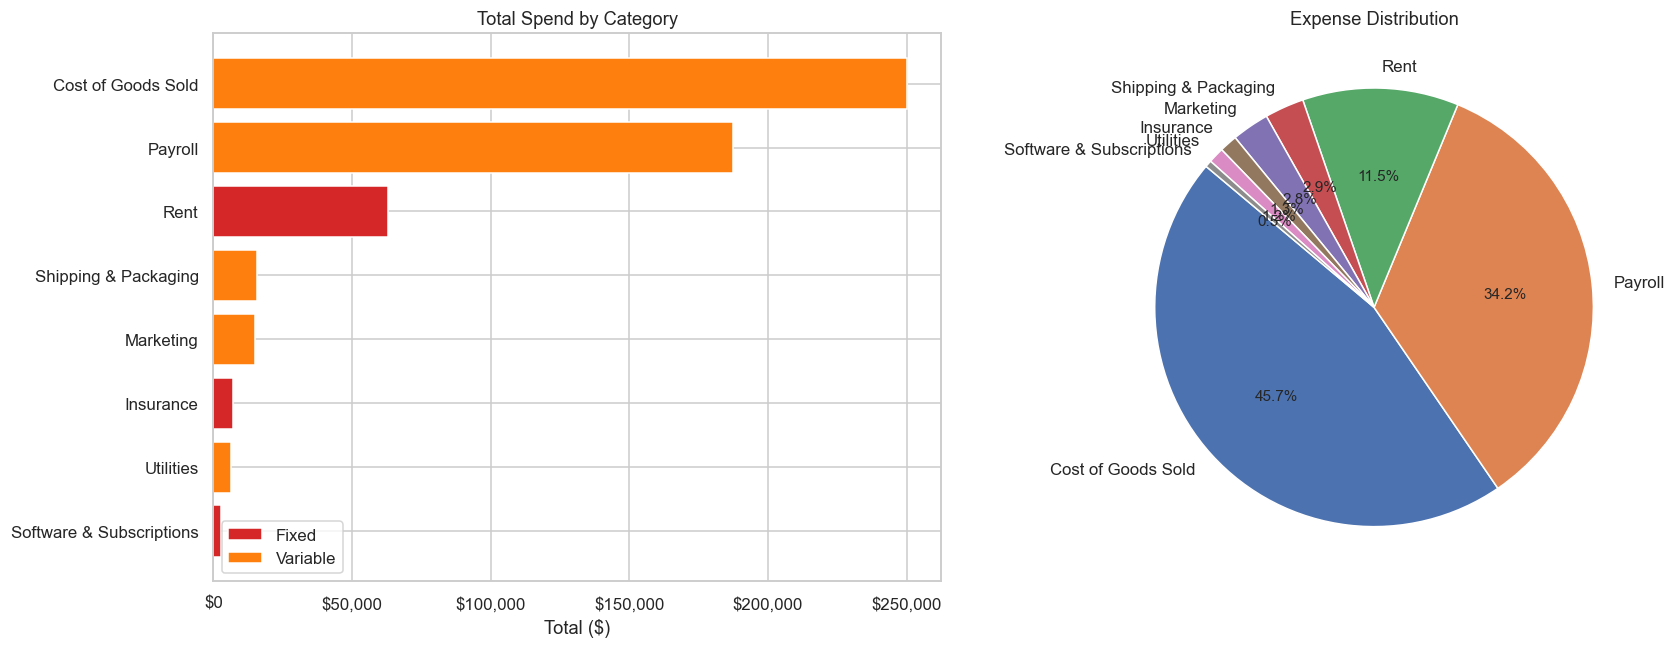

In [27]:
# Fixed vs variable cost split
cost_split = expenses.groupby('cost_type')['amount'].agg(['sum','mean']).round(2)
cost_split['pct'] = (cost_split['sum'] / cost_split['sum'].sum() * 100).round(1)
print("Fixed vs Variable Cost Split:")
print(cost_split.to_string())
print()

# By category
cat_exp = expenses.groupby(['category','cost_type'])['amount'].sum().reset_index()
cat_exp = cat_exp.sort_values('amount', ascending=False)
print("By Category:")
print(cat_exp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(cat_exp['category'][::-1], cat_exp['amount'][::-1],
             color=[RED if t=='Fixed' else ORANGE for t in cat_exp['cost_type'][::-1]])
axes[0].set_title("Total Spend by Category")
axes[0].set_xlabel("Total ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=RED,label='Fixed'), Patch(facecolor=ORANGE,label='Variable')])

axes[1].pie(cat_exp['amount'], labels=cat_exp['category'], autopct='%1.1f%%', startangle=140)
axes[1].set_title("Expense Distribution")

plt.tight_layout()
plt.show()

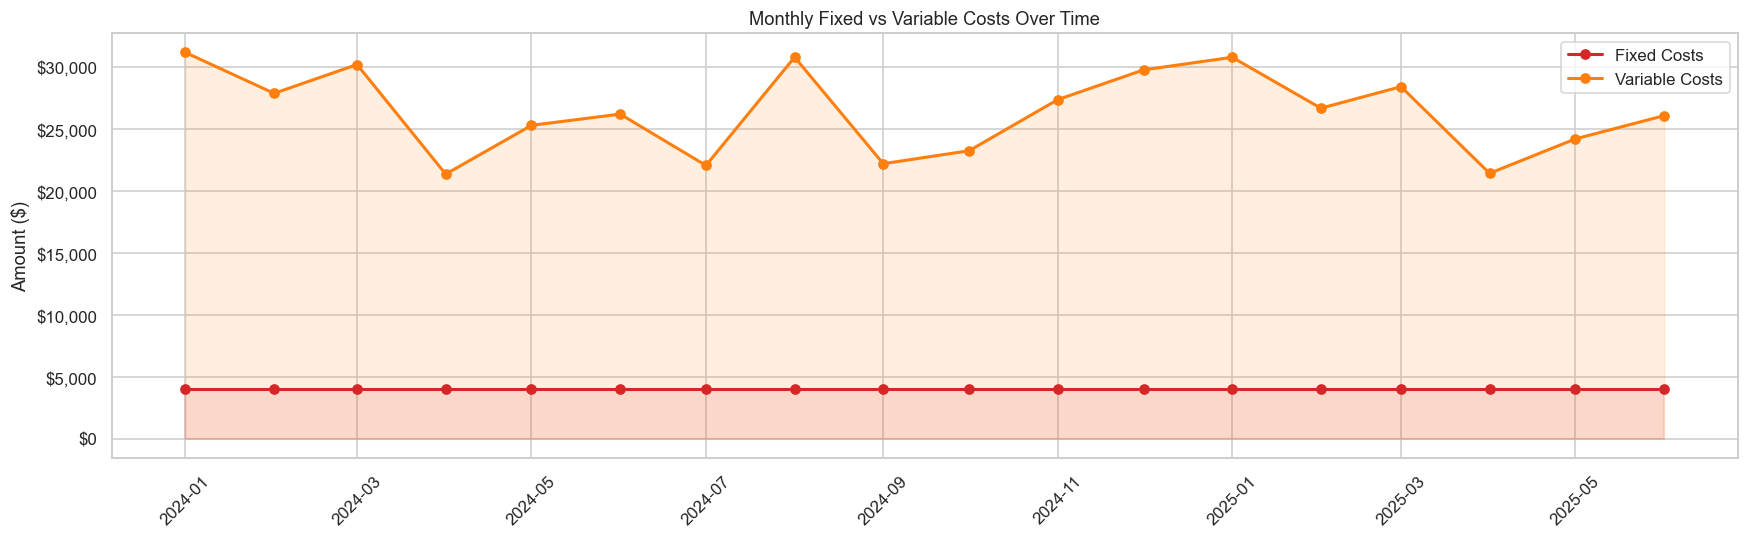

In [28]:
# Monthly fixed vs variable cost trend
monthly_exp = expenses.groupby(['month','cost_type'])['amount'].sum().reset_index()
monthly_exp['month_dt'] = monthly_exp['month'].dt.to_timestamp()

fixed_m    = monthly_exp[monthly_exp['cost_type']=='Fixed']
variable_m = monthly_exp[monthly_exp['cost_type']=='Variable']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(fixed_m['month_dt'],    fixed_m['amount'],    color=RED,    marker='o', linewidth=2, label='Fixed Costs')
ax.plot(variable_m['month_dt'], variable_m['amount'], color=ORANGE, marker='o', linewidth=2, label='Variable Costs')
ax.fill_between(fixed_m['month_dt'],    fixed_m['amount'],    alpha=0.12, color=RED)
ax.fill_between(variable_m['month_dt'], variable_m['amount'], alpha=0.12, color=ORANGE)
ax.set_title("Monthly Fixed vs Variable Costs Over Time")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Inventory EDA

Stock health summary (stock_level / reorder_point):
count    13675.00
mean         2.63
std          1.00
min          1.00
25%          1.78
50%          2.55
75%          3.35
max          5.00
Name: stock_health, dtype: float64

Records with stock_health < 1.0 (below reorder point): 0 (0.0%)
Records with is_near_stockout: 96


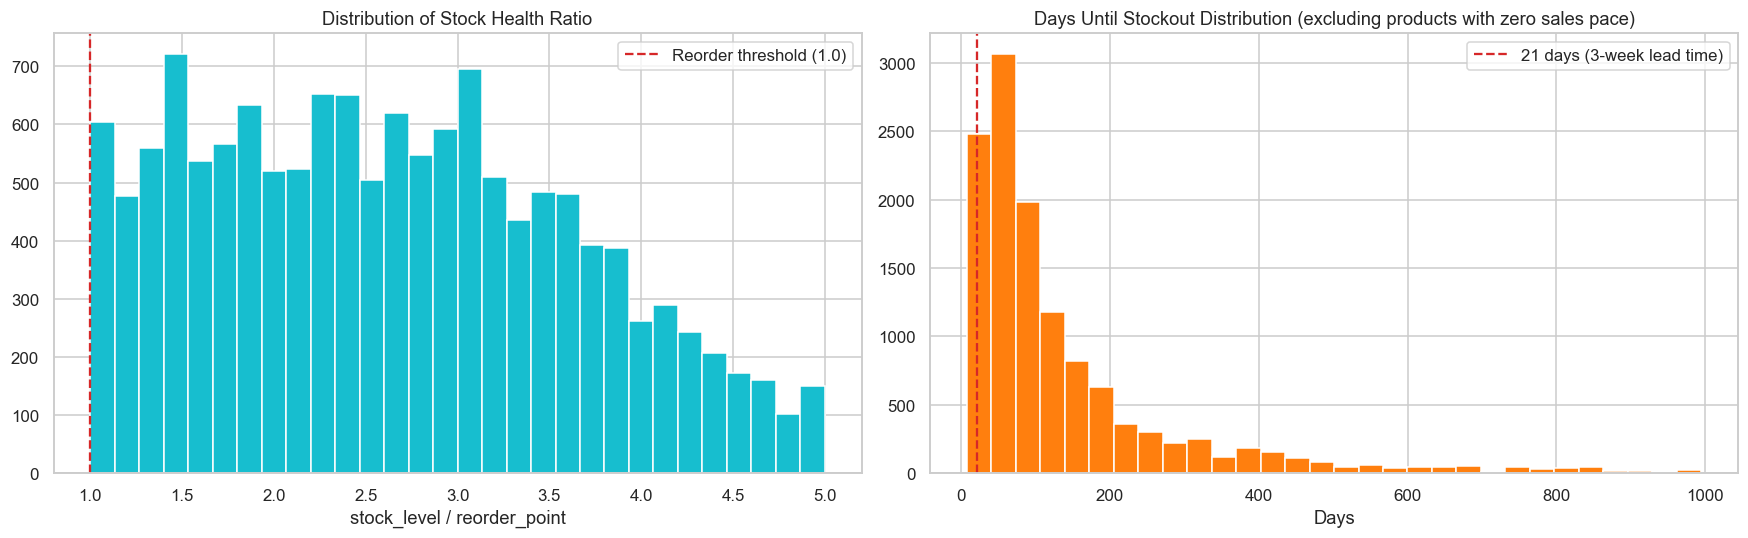

In [30]:
# Stock health distribution
print("Stock health summary (stock_level / reorder_point):")
print(inventory['stock_health'].describe().round(2))
print()
print(f"Records with stock_health < 1.0 (below reorder point): "
      f"{(inventory['stock_health'] < 1.0).sum():,} "
      f"({(inventory['stock_health'] < 1.0).mean()*100:.1f}%)")
print(f"Records with is_near_stockout: {inventory['is_near_stockout'].sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(inventory['stock_health'], bins=30, color=TEAL, edgecolor='white')
axes[0].axvline(1.0, color=RED, linestyle='--', label='Reorder threshold (1.0)')
axes[0].set_title("Distribution of Stock Health Ratio")
axes[0].set_xlabel("stock_level / reorder_point")
axes[0].legend()

# Days until stockout distribution (exclude 999 = no risk)
real_risk = inventory[inventory['days_until_stockout'] < 999]['days_until_stockout']
axes[1].hist(real_risk, bins=30, color=ORANGE, edgecolor='white')
axes[1].axvline(21, color=RED, linestyle='--', label='21 days (3-week lead time)')
axes[1].set_title("Days Until Stockout Distribution (excluding products with zero sales pace)")
axes[1].set_xlabel("Days")
axes[1].legend()

plt.tight_layout()
plt.show()

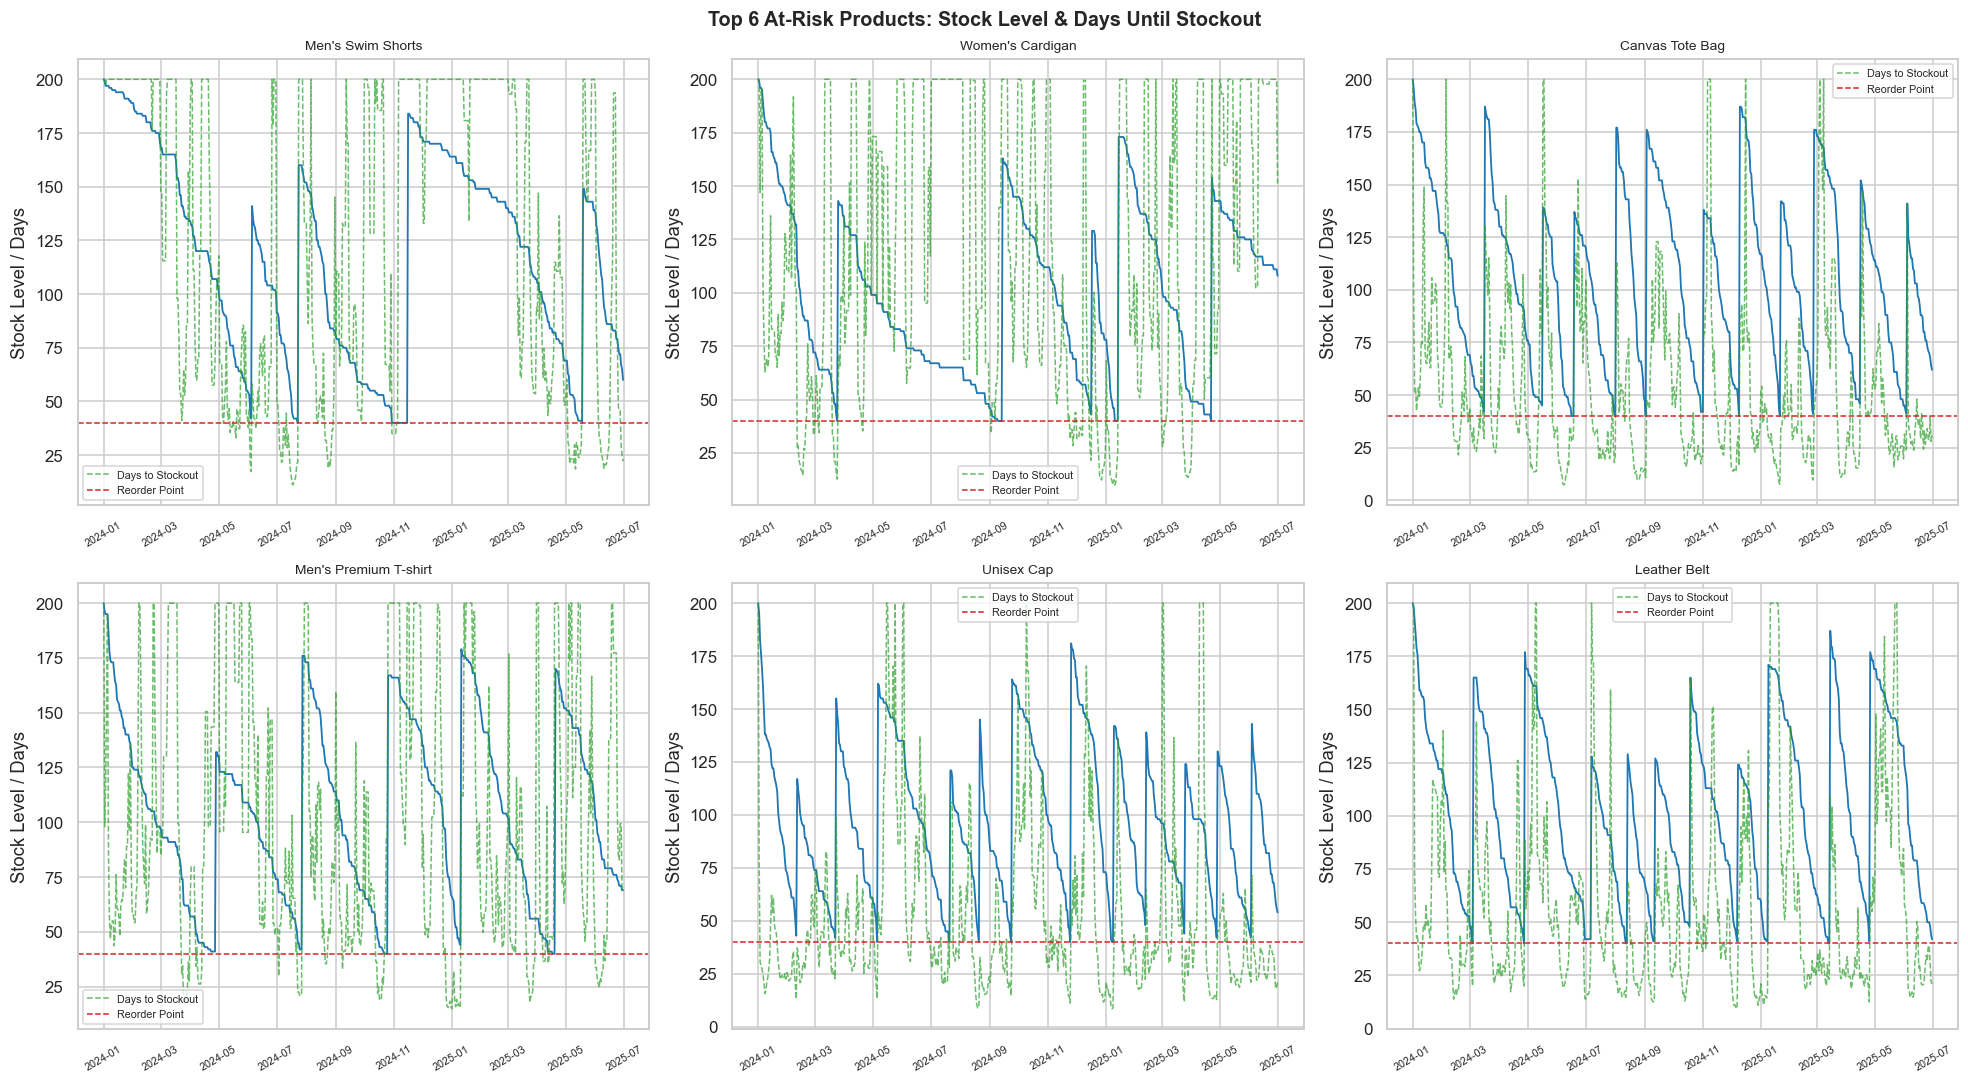

In [31]:
# Stock depletion over time — top 6 most at-risk products by near-stockout days
at_risk = inventory.groupby('product_name')['is_near_stockout'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, product in enumerate(at_risk):
    prod_data = inventory[inventory['product_name'] == product].sort_values('date')
    axes[i].plot(prod_data['date'], prod_data['stock_level'], color=BLUE, linewidth=1.2)
    axes[i].plot(prod_data['date'], prod_data['days_until_stockout'].clip(upper=200),
                 color=GREEN, linewidth=1, linestyle='--', alpha=0.7, label='Days to Stockout')
    axes[i].axhline(prod_data['reorder_point'].iloc[0], color=RED, linestyle='--',
                    linewidth=1, label='Reorder Point')
    axes[i].set_title(product, fontsize=9)
    axes[i].set_ylabel("Stock Level / Days")
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle("Top 6 At-Risk Products: Stock Level & Days Until Stockout", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

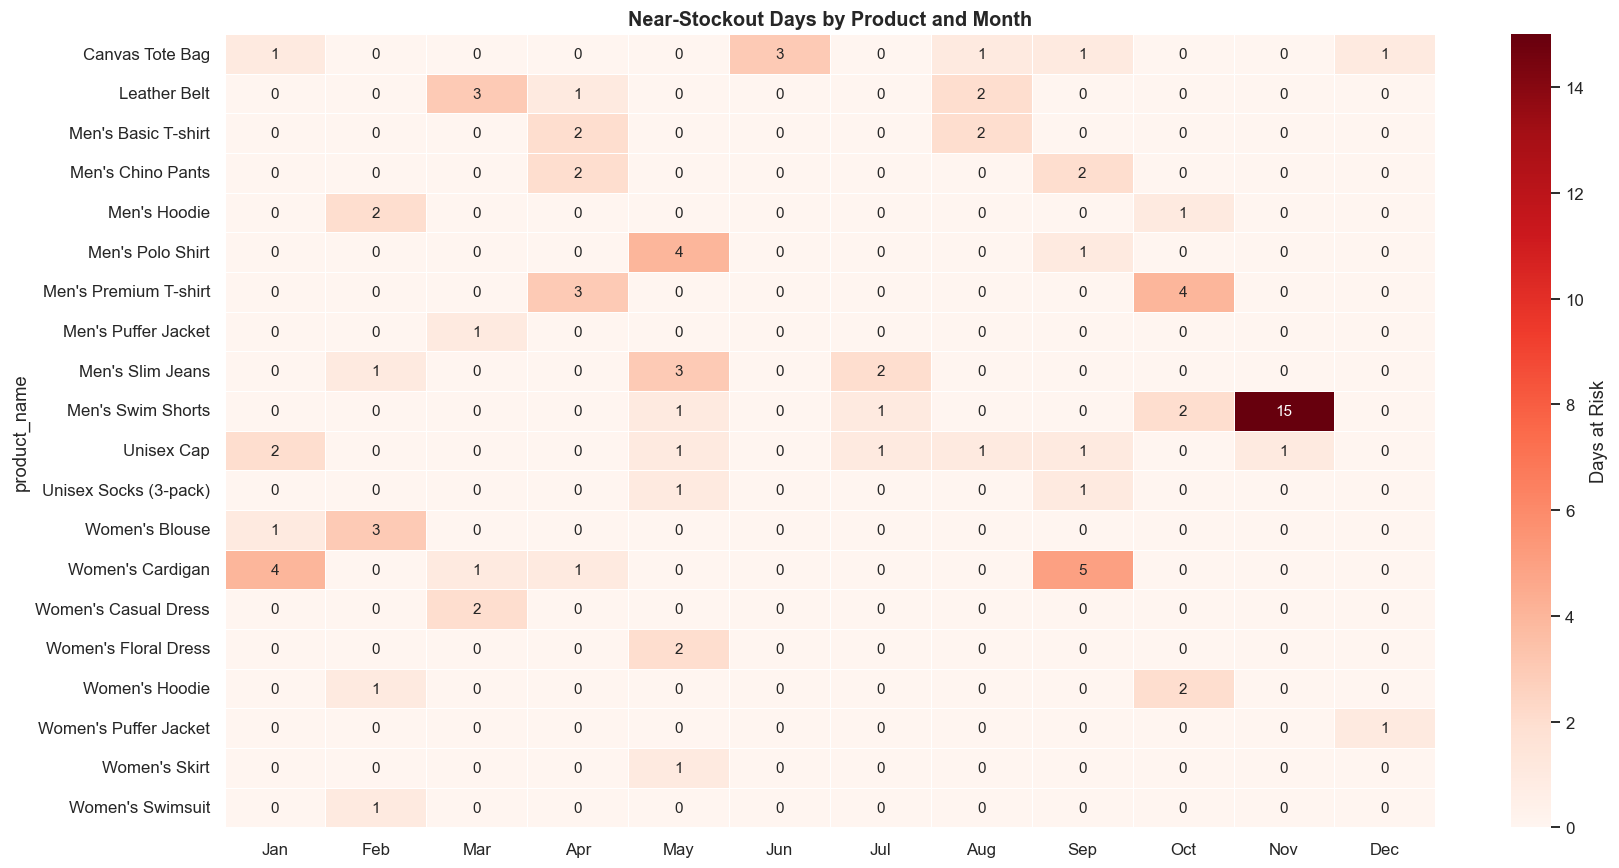

In [32]:
# Near-stockout heatmap by product and month
near_so = inventory[inventory['is_near_stockout']].copy()
near_so['month_num'] = near_so['date'].dt.month

heatmap_data = near_so.groupby(['product_name','month_num']).size().reset_index(name='days_at_risk')
heatmap_pivot = heatmap_data.pivot(index='product_name', columns='month_num', values='days_at_risk').fillna(0)

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
heatmap_pivot.columns = [month_names.get(c,c) for c in heatmap_pivot.columns]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label':'Days at Risk'})
plt.title("Near-Stockout Days by Product and Month", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- The heatmap is the single most actionable inventory output in this project. Red cells by month and product are the exact reorder windows. Products with red in Oct–Dec need winter stock. Products with red in Jun–Aug need summer stock. The days_until_stockout feature from FE adds the forward-looking dimension — not just when past stockouts happened, but how close current stock is to running out.

### Cross-Dataset Relationships

##### 1.  Revenue vs Expenses ~Monthly P&L

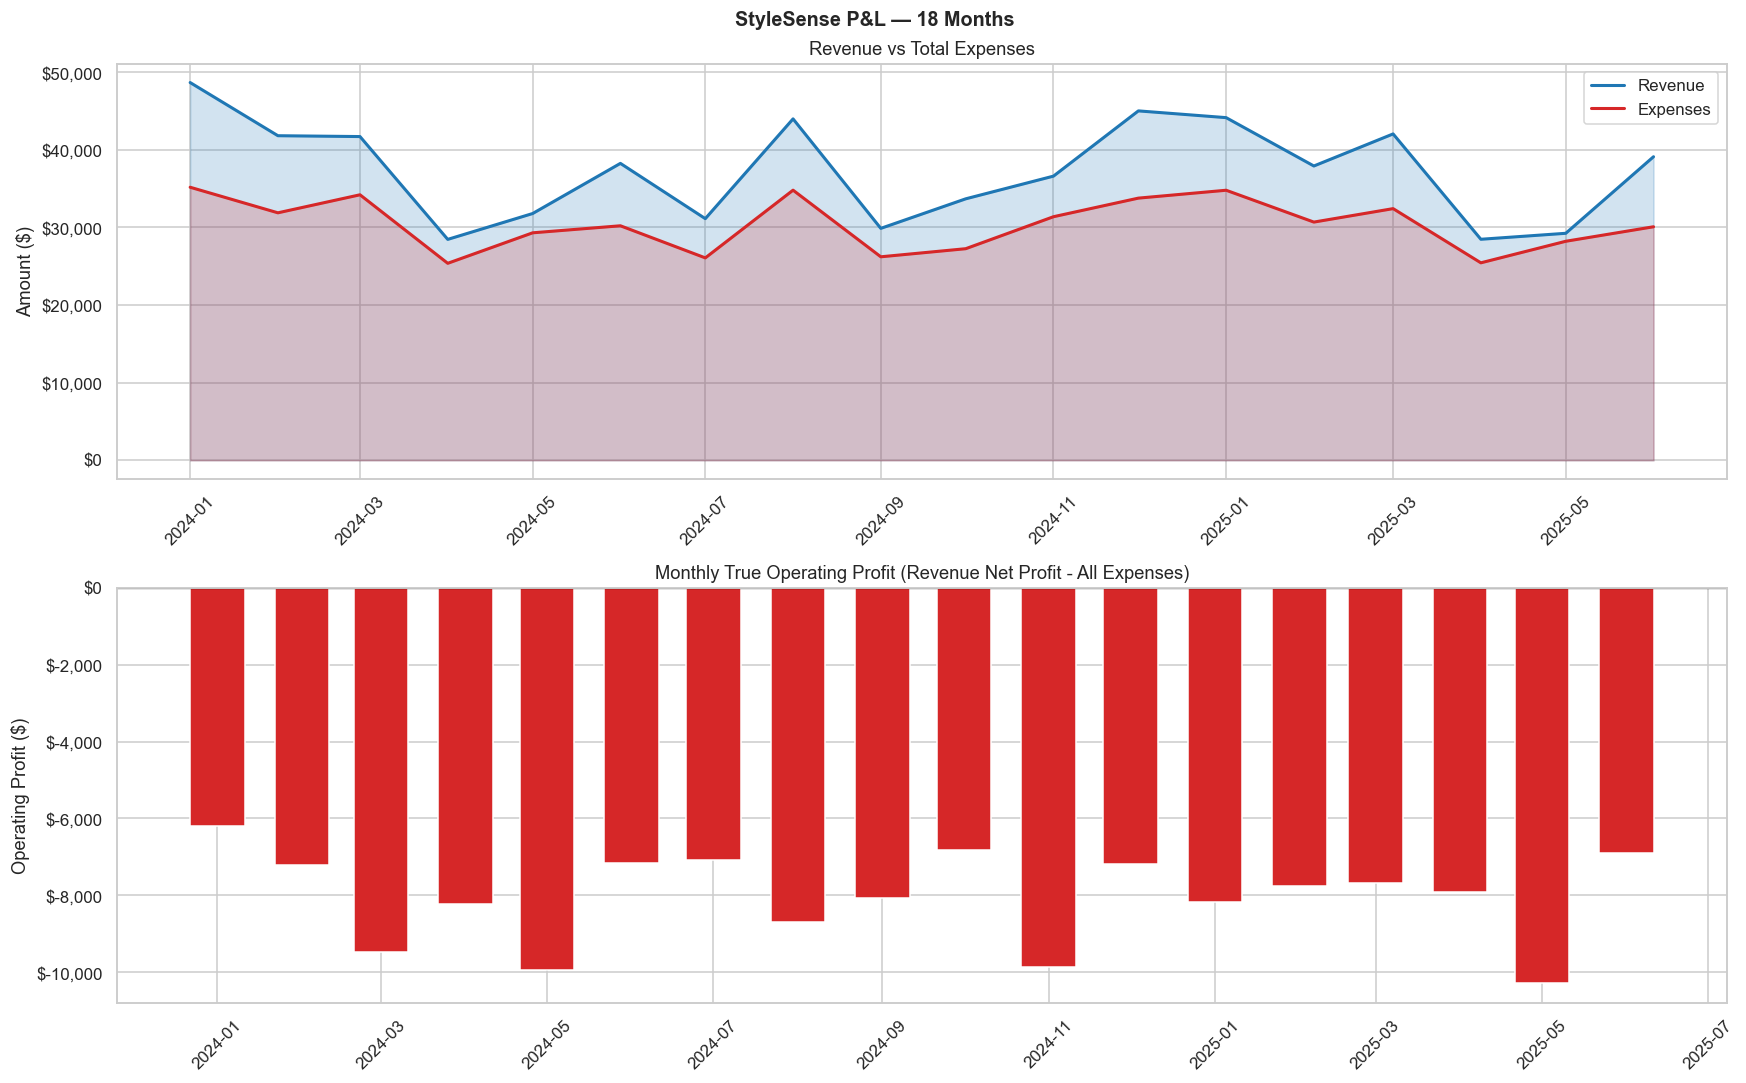

  month  revenue  expenses  true_profit
2024-01 48676.10  35186.46     -6201.29
2024-02 41826.37  31892.38     -7223.30
2024-03 41717.20  34215.46     -9459.50
2024-04 28469.56  25386.92     -8222.16
2024-05 31800.97  29315.40     -9940.45
2024-06 38262.66  30221.78     -7148.72
2024-07 31139.84  26085.15     -7077.40
2024-08 43995.76  34810.01     -8703.83
2024-09 29888.35  26225.41     -8059.85
2024-10 33694.93  27267.85     -6827.23
2024-11 36618.58  31388.59     -9869.97
2024-12 45025.71  33784.47     -7190.04
2025-01 44155.95  34800.35     -8181.00
2025-02 37925.25  30697.41     -7745.49
2025-03 42057.40  32431.75     -7674.00
2025-04 28483.59  25449.45     -7924.00
2025-05 29253.64  28225.54    -10289.48
2025-06 39117.08  30095.04     -6901.96


In [33]:
monthly_rev = sales.groupby('month').agg(
    revenue    = ('total_sale', 'sum'),
    net_profit = ('net_profit', 'sum')
).reset_index()

monthly_cost = expenses.groupby('month')['amount'].sum().reset_index()
monthly_cost.columns = ['month','expenses']

pnl = monthly_rev.merge(monthly_cost, on='month', how='inner')
pnl['true_profit'] = pnl['net_profit'] - pnl['expenses']
pnl['month_dt']    = pnl['month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].fill_between(pnl['month_dt'], pnl['revenue'],   alpha=0.2, color=BLUE)
axes[0].fill_between(pnl['month_dt'], pnl['expenses'],  alpha=0.2, color=RED)
axes[0].plot(pnl['month_dt'], pnl['revenue'],  color=BLUE,  linewidth=2, label='Revenue')
axes[0].plot(pnl['month_dt'], pnl['expenses'], color=RED,   linewidth=2, label='Expenses')
axes[0].set_title("Revenue vs Total Expenses")
axes[0].set_ylabel("Amount ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

bar_colors = [GREEN if v >= 0 else RED for v in pnl['true_profit']]
axes[1].bar(pnl['month_dt'], pnl['true_profit'], color=bar_colors, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Monthly True Operating Profit (Revenue Net Profit - All Expenses)")
axes[1].set_ylabel("Operating Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("StyleSense P&L — 18 Months", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(pnl[['month','revenue','expenses','true_profit']].to_string(index=False))

##### 2. RFM Segments: Actual Purchase Behaviour in Sales

In [34]:
# Join sales transactions to RFM segments
sales_rfm = sales.merge(
    customers[['customer_id','RFM_segment','segment','age_group']],
    on='customer_id', how='inner'
)

print(f"Transactions matched to a customer: {len(sales_rfm):,} of {len(sales):,}")
print()

rfm_sales = sales_rfm.groupby('RFM_segment').agg(
    transactions    = ('sale_id', 'count'),
    total_revenue   = ('total_sale', 'sum'),
    avg_order_value = ('total_sale', 'mean'),
    avg_margin      = ('profit_margin_pct', 'mean'),
    avg_discount    = ('discount_pct', 'mean'),
    return_rate     = ('is_returned', 'mean')
).reset_index()

rfm_sales['return_rate'] = (rfm_sales['return_rate'] * 100).round(1)
rfm_sales['avg_margin']  = rfm_sales['avg_margin'].round(1)
rfm_sales['avg_discount']= rfm_sales['avg_discount'].round(1)

seg_order = ['Champion','Loyal','Potential','At Risk','Lost']
rfm_sales['RFM_segment'] = pd.Categorical(rfm_sales['RFM_segment'], categories=seg_order, ordered=True)
rfm_sales = rfm_sales.sort_values('RFM_segment')

print("Sales Behaviour by RFM Segment:")
print(rfm_sales[['RFM_segment','transactions','total_revenue','avg_order_value',
                  'avg_margin','avg_discount','return_rate']].to_string(index=False))

Transactions matched to a customer: 9,889 of 9,989

Sales Behaviour by RFM Segment:
RFM_segment  transactions  total_revenue  avg_order_value  avg_margin  avg_discount  return_rate
   Champion           759       59620.90        78.551910        60.8           5.3          5.7
      Loyal          3494      255075.73        73.003930        61.5           5.3          4.6
  Potential          2669      178575.83        66.907392        61.5           5.4          4.5
    At Risk          1889      112062.85        59.323902        60.5           5.5          6.0
       Lost          1078       59960.23        55.621735        62.2           4.8          4.0


##### 3. Seasonal Product Sales vs Inventory Stock

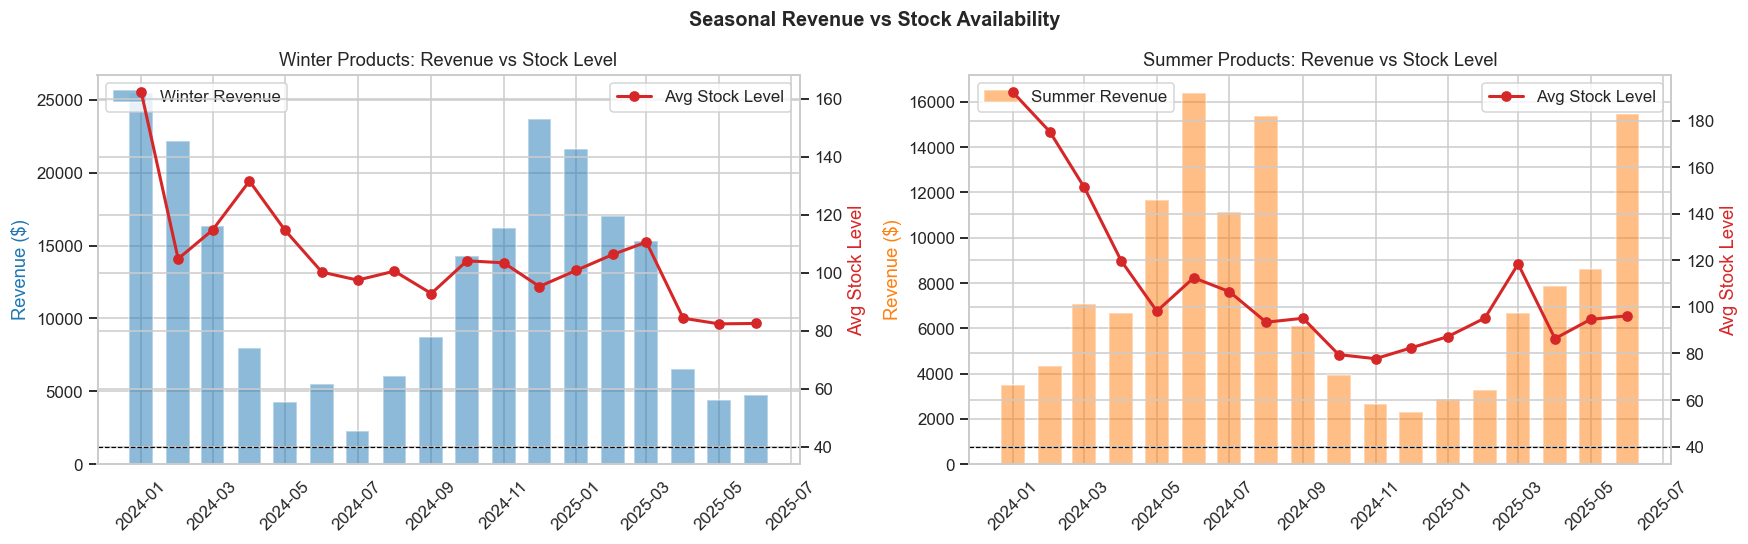

In [35]:
# Monthly sales revenue for winter vs summer products
seasonal_sales = sales[sales['season'].isin(['Winter','Summer'])].copy()
seasonal_monthly = seasonal_sales.groupby(['month','season'])['total_sale'].sum().reset_index()
seasonal_monthly['month_dt'] = seasonal_monthly['month'].dt.to_timestamp()

winter_sales = seasonal_monthly[seasonal_monthly['season']=='Winter']
summer_sales = seasonal_monthly[seasonal_monthly['season']=='Summer']

# Monthly avg stock for seasonal products
inv_seasonal = inventory.merge(products[['product_id','season']], on='product_id', how='left')
inv_seasonal = inv_seasonal[inv_seasonal['season'].isin(['Winter','Summer'])]
inv_monthly = inv_seasonal.groupby(['month','season'])['stock_level'].mean().reset_index()
inv_monthly['month_dt'] = inv_monthly['month'].dt.to_timestamp()

winter_stock = inv_monthly[inv_monthly['season']=='Winter']
summer_stock = inv_monthly[inv_monthly['season']=='Summer']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax_w2 = axes[0].twinx()
axes[0].bar(winter_sales['month_dt'], winter_sales['total_sale'],
            width=20, alpha=0.5, color=BLUE, label='Winter Revenue')
ax_w2.plot(winter_stock['month_dt'], winter_stock['stock_level'],
           color=RED, marker='o', linewidth=2, label='Avg Stock Level')
ax_w2.axhline(40, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title("Winter Products: Revenue vs Stock Level")
axes[0].set_ylabel("Revenue ($)", color=BLUE)
ax_w2.set_ylabel("Avg Stock Level", color=RED)
axes[0].legend(loc='upper left')
ax_w2.legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

ax_s2 = axes[1].twinx()
axes[1].bar(summer_sales['month_dt'], summer_sales['total_sale'],
            width=20, alpha=0.5, color=ORANGE, label='Summer Revenue')
ax_s2.plot(summer_stock['month_dt'], summer_stock['stock_level'],
           color=RED, marker='o', linewidth=2, label='Avg Stock Level')
ax_s2.axhline(40, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Summer Products: Revenue vs Stock Level")
axes[1].set_ylabel("Revenue ($)", color=ORANGE)
ax_s2.set_ylabel("Avg Stock Level", color=RED)
axes[1].legend(loc='upper left')
ax_s2.legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Seasonal Revenue vs Stock Availability", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- When revenue is rising for a seasonal product but stock level is simultaneously falling toward the reorder point, StyleSense is at risk of missing peak demand. The ideal pattern is stock arriving before the revenue peak, not after. Any month where the stock line crosses the reorder threshold while revenue is still high is a lost-sales event.